### Problem Definition
- **What problem are we solving?** Classifying breast cancer tumors as Malignant or Benign based on digitized images.
- **Why is this problem important?** Medical diagnosis automation reduces human error and speeds up life-saving treatment.
- **What type of ML problem is this?** Supervised Binary Classification.

---

### Dataset
- **What information does this dataset contain?** Geometric measurements of cell nuclei (radius, texture, perimeter).
- **What is the target?** Diagnosis (M = Malignant, B = Benign).

In [64]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

print(data.DESCR)
print(data.data.shape)
print(data.target)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [65]:
import pandas as pd

pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)

df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error  \
0                

### Exploratory Data Analysis
- **What should we learn from EDA?** Identifying which geometric features have the widest separation between Malignant and Benign classes.

In [66]:
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error  \
0                

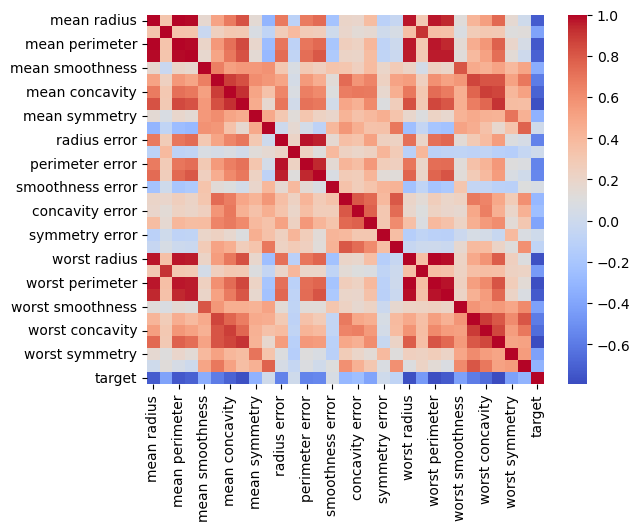

target
1    357
0    212
Name: count, dtype: int64
target
1    62.741652
0    37.258348
Name: proportion, dtype: float64


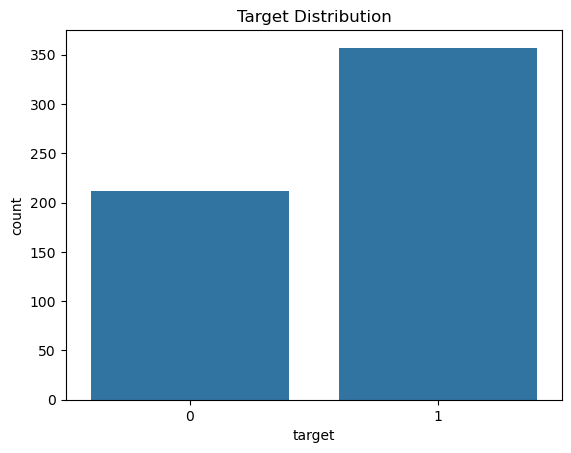

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', fmt='.4f')
plt.show()

print(df['target'].value_counts())

print(df['target'].value_counts(normalize=True) * 100)

sns.countplot(x='target', data=df)

plt.title("Target Distribution")
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [68]:
import numpy as np

X = df.drop(columns='target')
y = df['target']

print(X.select_dtypes(include='number').skew())
print(y.skew())

skewed_features = ["radius error", "perimeter error", "area error", "concavity error", "fractal dimension error"]

for col in skewed_features:
    X[col] = np.log1p(X[col])

mean radius                0.942380
mean texture               0.650450
mean perimeter             0.990650
mean area                  1.645732
mean smoothness            0.456324
mean compactness           1.190123
mean concavity             1.401180
mean concave points        1.171180
mean symmetry              0.725609
mean fractal dimension     1.304489
radius error               3.088612
texture error              1.646444
perimeter error            3.443615
area error                 5.447186
smoothness error           2.314450
compactness error          1.902221
concavity error            5.110463
concave points error       1.444678
symmetry error             2.195133
fractal dimension error    3.923969
worst radius               1.103115
worst texture              0.498321
worst perimeter            1.128164
worst area                 1.859373
worst smoothness           0.415426
worst compactness          1.473555
worst concavity            1.150237
worst concave points       0

### Data Preprocessing
- **Scaling:** Scaling is absolutely critical here. Geometric measurements are on wildly different scales (e.g., area in thousands vs smoothness in decimals).

In [69]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.80)

In [70]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Selection
- **Why choose this algorithm?** Support Vector Machines (SVM) excel at finding the maximum margin hyperplane between two distinct classes in high-dimensional space.

In [71]:
from sklearn.linear_model import LogisticRegressionCV

logistic_model = LogisticRegressionCV(
    cv=5,
    scoring='accuracy',
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

y_prob = logistic_model.predict_proba(X_test_scaled)
print(y_prob[:5])

print(logistic_model.C_)

[[1.51399716e-01 8.48600284e-01]
 [9.99998725e-01 1.27481918e-06]
 [9.99495194e-01 5.04806347e-04]
 [2.43905041e-05 9.99975609e-01]
 [1.05433009e-05 9.99989457e-01]]
[2.7825594]


### Evaluation
- **Why these metrics?** Recall is the absolute most important metric here.
- **How should they be interpreted?** A False Negative (predicting Benign when it's actually Malignant) is a fatal error. We must maximize Recall to ensure we catch every single cancer case.

In [72]:
from sklearn.svm import SVC

# Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
linear_svm = SVC(kernel='linear', probability=True, random_state=42)

linear_svm.fit(X_train_scaled, y_train)

linear_pred = linear_svm.predict(X_test_scaled)
linear_prob = linear_svm.predict_proba(X_test_scaled)[:, 1]

In [73]:
from sklearn.svm import SVC

# Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
rbf_svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

rbf_svm.fit(X_train_scaled, y_train)

rbf_pred = rbf_svm.predict(X_test_scaled)
rbf_prob = rbf_svm.predict_proba(X_test_scaled)[:, 1]

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss
)

metrics = []

if y_prob.ndim == 2:
    y_prob = y_prob[:, 1]

if linear_prob.ndim == 2:
    linear_prob = linear_prob[:, 1]

if rbf_prob.ndim == 2:
    rbf_prob = rbf_prob[:, 1]

for name, y_pred_model, y_prob_model in [
    ("Logistic Regression", y_pred, y_prob),
    ("Linear SVM", linear_pred, linear_prob),
    ("RBF SVM", rbf_pred, rbf_prob),
]:

    metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_model),
        "Precision": precision_score(y_test, y_pred_model),
        "Recall": recall_score(y_test, y_pred_model),
        # Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
        "F1 Score": f1_score(y_test, y_pred_model),
        # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
        "ROC AUC": roc_auc_score(y_test, y_prob_model),
        "Log Loss": log_loss(y_test, y_prob_model)
    })

metrics_df = pd.DataFrame(metrics).set_index("Model").round(4)

print(metrics_df)

                     Accuracy  Precision  Recall  F1 Score  ROC AUC  Log Loss
Model                                                                        
Logistic Regression    0.9825     0.9859  0.9859    0.9859   0.9971    0.0611
Linear SVM             0.9561     0.9714  0.9577    0.9645   0.9964    0.0771
RBF SVM                0.9737     0.9722  0.9859    0.9790   0.9974    0.0722


In [75]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

# Perform an exhaustive search across the hyperparameter grid with cross-validation to locate the global optimum.
grid = GridSearchCV(
    # Find the optimal maximum-margin hyperplane that separates classes in a high-dimensional feature space.
    SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 1, 'gamma': 'scale'}
0.9957688338493291


In [76]:
best_svm = grid.best_estimator_
best_pred = best_svm.predict(X_test_scaled)
best_prob = best_svm.predict_proba(X_test_scaled)

if best_prob.ndim == 2:
    best_prob = best_prob[:, 1]

print(f"Accuracy : {accuracy_score(y_test, best_pred):.4f}")
print(f"Precision: {precision_score(y_test, best_pred, average='weighted'):.4f}")
print(f"Recall : {recall_score(y_test, best_pred, average='weighted'):.4f}")
# Calculate the harmonic mean of Precision and Recall. Highly preferred over Accuracy when evaluating imbalanced datasets.
print(f"F1 Score : {f1_score(y_test, best_pred, average='weighted'):.4f}")
# Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
print(f"ROC-AUC : {roc_auc_score(y_test, best_prob, multi_class='ovr'):.4f}")
print(f"Log Loss : {log_loss(y_test, best_prob):.4f}")


Accuracy : 0.9737
Precision: 0.9737
Recall : 0.9737
F1 Score : 0.9736
ROC-AUC : 0.9974
Log Loss : 0.0722


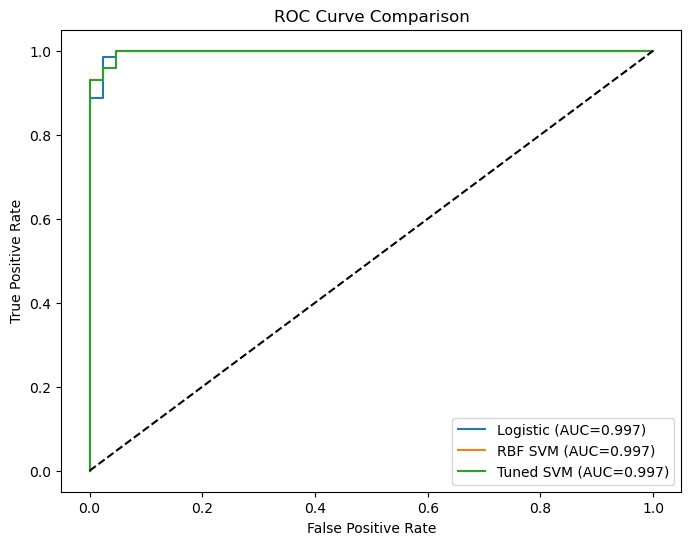

In [77]:
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(y_test, y_prob)

rbf_fpr, rbf_tpr, _ = roc_curve(y_test, rbf_prob)

best_fpr, best_tpr, _ = roc_curve(y_test, best_prob)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr,
         # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
         label=f"Logistic (AUC={roc_auc_score(y_test,y_prob):.3f})")

plt.plot(rbf_fpr, rbf_tpr,
         # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
         label=f"RBF SVM (AUC={roc_auc_score(y_test,rbf_prob):.3f})")

plt.plot(best_fpr, best_tpr,
         # Quantify the model's overall ability to discriminate between classes across all possible classification thresholds.
         label=f"Tuned SVM (AUC={roc_auc_score(y_test,best_prob):.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### Visualization Analysis: ROC Curve & AUC
- **Marking Values:** The critical value is the AUC (Area Under Curve) score. 0.5 is random guessing, 1.0 is a perfect model. Look at where the curve 'bows' towards the top-left (True Positive Rate = 1, False Positive Rate = 0).
- **Correct Interpretation:** The steeper the curve shoots upward before bending right, the better the model is at separating classes at various probability thresholds.
- **How to Interpret:** The X-axis is the False Positive Rate (cost). The Y-axis is the True Positive Rate (benefit). We want maximum benefit for minimum cost.
- **Common Mistakes:** Using ROC-AUC to evaluate models on severely imbalanced datasets. (Use PR-AUC instead).

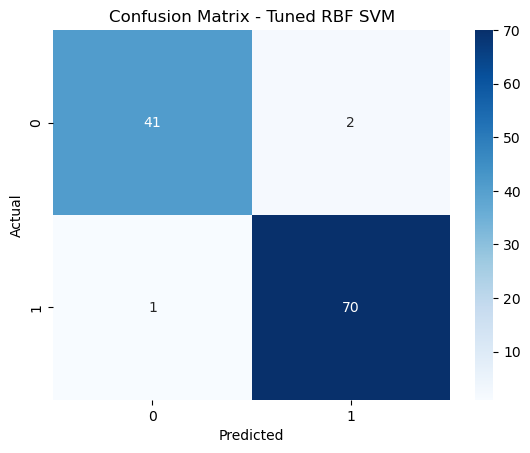

In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned RBF SVM")

plt.show()

### Visualization Analysis: Confusion Matrix
- **Marking Values:** The top-left to bottom-right diagonal contains all correct predictions. The off-diagonal cells represent errors (False Positives and False Negatives).
- **Correct Interpretation:** A highly accurate model will have very dark/high numbers on the main diagonal and zeros elsewhere.
- **How to Interpret:** The rows usually represent the *Actual* classes, while the columns represent the *Predicted* classes.
- **Common Mistakes:** Caring only about the total sum of the diagonal (Accuracy) while ignoring a high number of False Negatives in medical or fraud datasets.

### Conclusion
- **Biggest takeaway:** In medical ML, optimizing for Recall is far more important than optimizing for raw Accuracy.
- **Possible improvements:** Using non-linear SVM kernels (RBF) to capture complex tumor geometries.